# Memory mushroom analysis

This notebook:

1. plots **all memory stimuli** (both mushrooms from every memory pair), by color
   - background = unique learning-phase seen mushrooms at 30% alpha
   - point color = seen vs unseen
   - unseen marker shape = lure bin (`1 = triangle`, `2 = square`)
   - no pair labels on this figure

2. plots **within-color memory pairs only**
   - same encoding as above
   - pair members are connected by a line
   - labeled with the original memory **pair number**

No CSV files are saved automatically.


Raw shape: (1709, 389)

Trial type counts:
trial_type
explore_decision              727
explore_seen                  716
odd_one_out                   100
memory_choice                  62
oldnew_response                61
room_choice                    25
post_survey_builder             8
color_blind_survey_plate        4
bis_bas_survey                  1
need_for_cognition_survey       1
five_dcr_survey                 1
color_blind_survey_summary      1
post_survey_demographics        1
post_survey                     1
Name: count, dtype: int64

Unique learning-phase seen mushrooms: 572
Clean memory pairs: 60
Memory stimuli rows (both sides together): 120
Within-color memory pairs: 29

Overview:


,metric,value
0,clean_memory_pairs,60
1,all_memory_stimuli,120
2,within_color_pairs,29
3,cross_color_pairs,31
4,unique_learning_seen_background,572



Memory stimuli by seen/unseen:


,status_group,n_memory_stimuli
0,seen,89
1,unseen,31



Memory stimuli by color and seen/unseen:


...

,item_lure_bin_num,n_unseen_memory_stimuli
0,1.0,7
1,2.0,24



Question-level lure difficulty counts:


,difficulty_label,lure_bin_num,n_pairs
0,,1.0,1
1,,2.0,9
2,,NaN,26
3,close,2.0,8
4,far,1.0,1
5,far,2.0,7
6,middle,2.0,8



Within-color pair counts by color:


,within_pair_color,n_within_color_pairs
0,black,3
1,blue,3
2,cyan,4
3,green,3
4,magenta,4
5,red,4
6,white,5
7,yellow,3


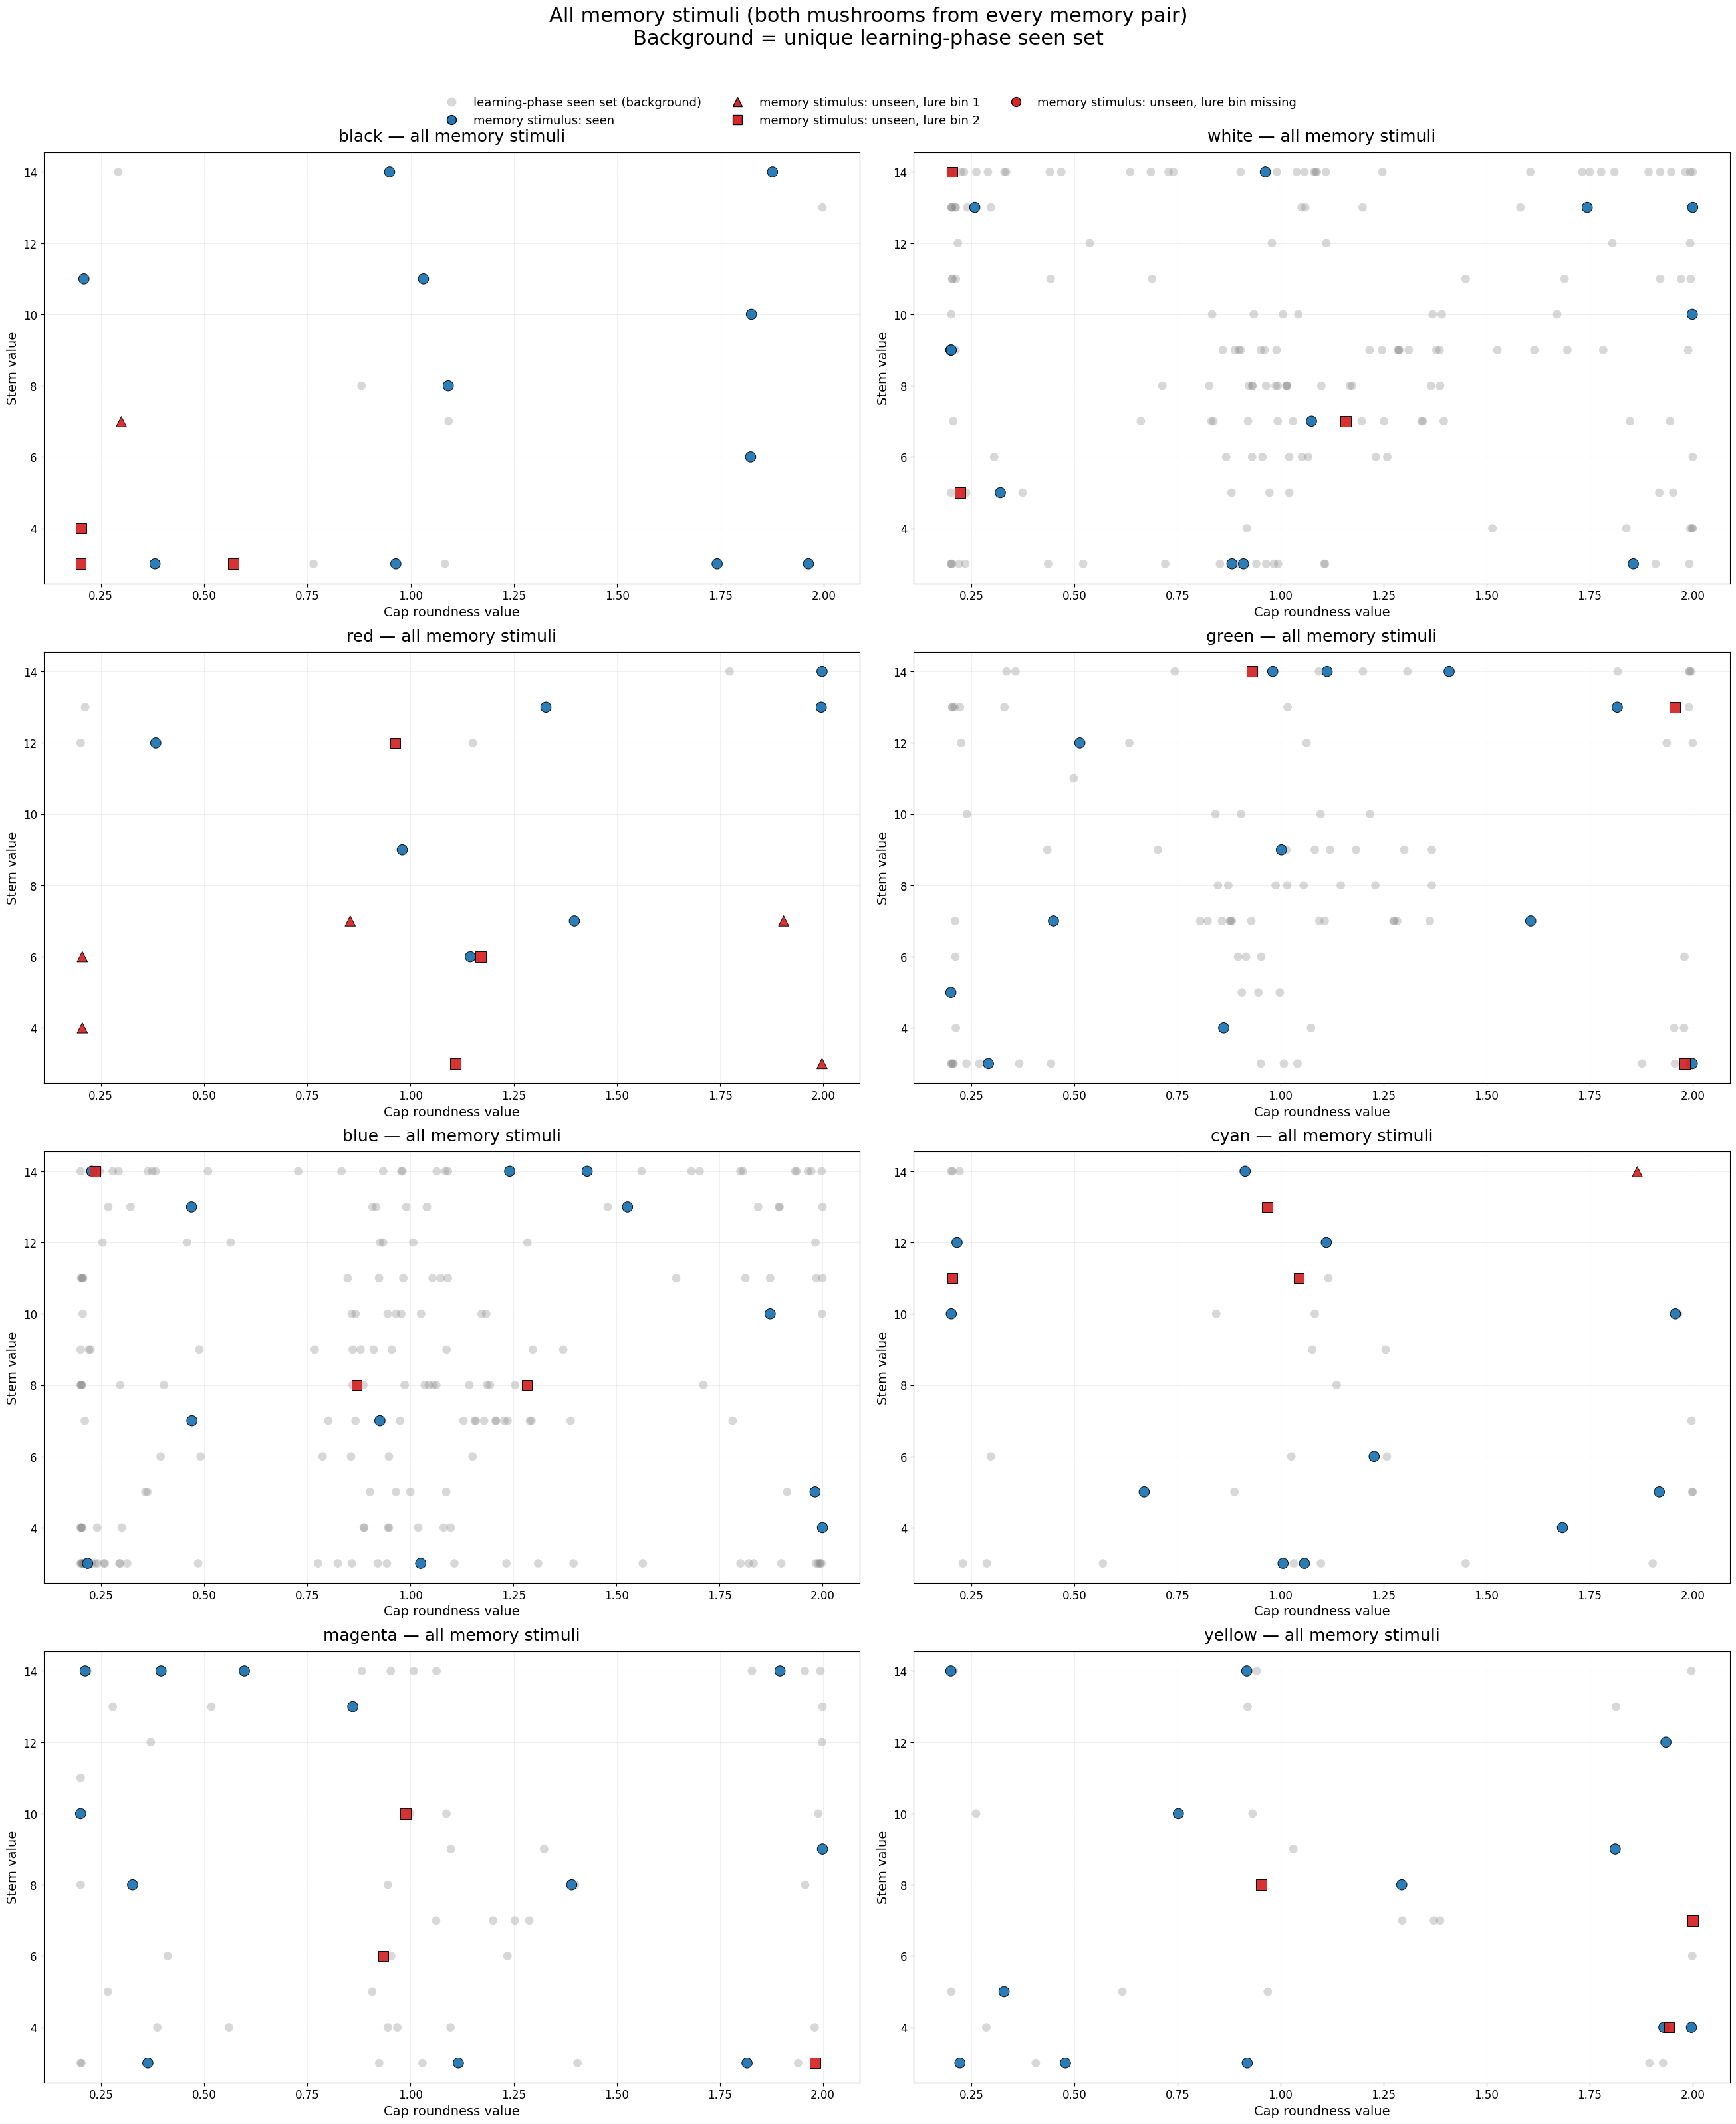

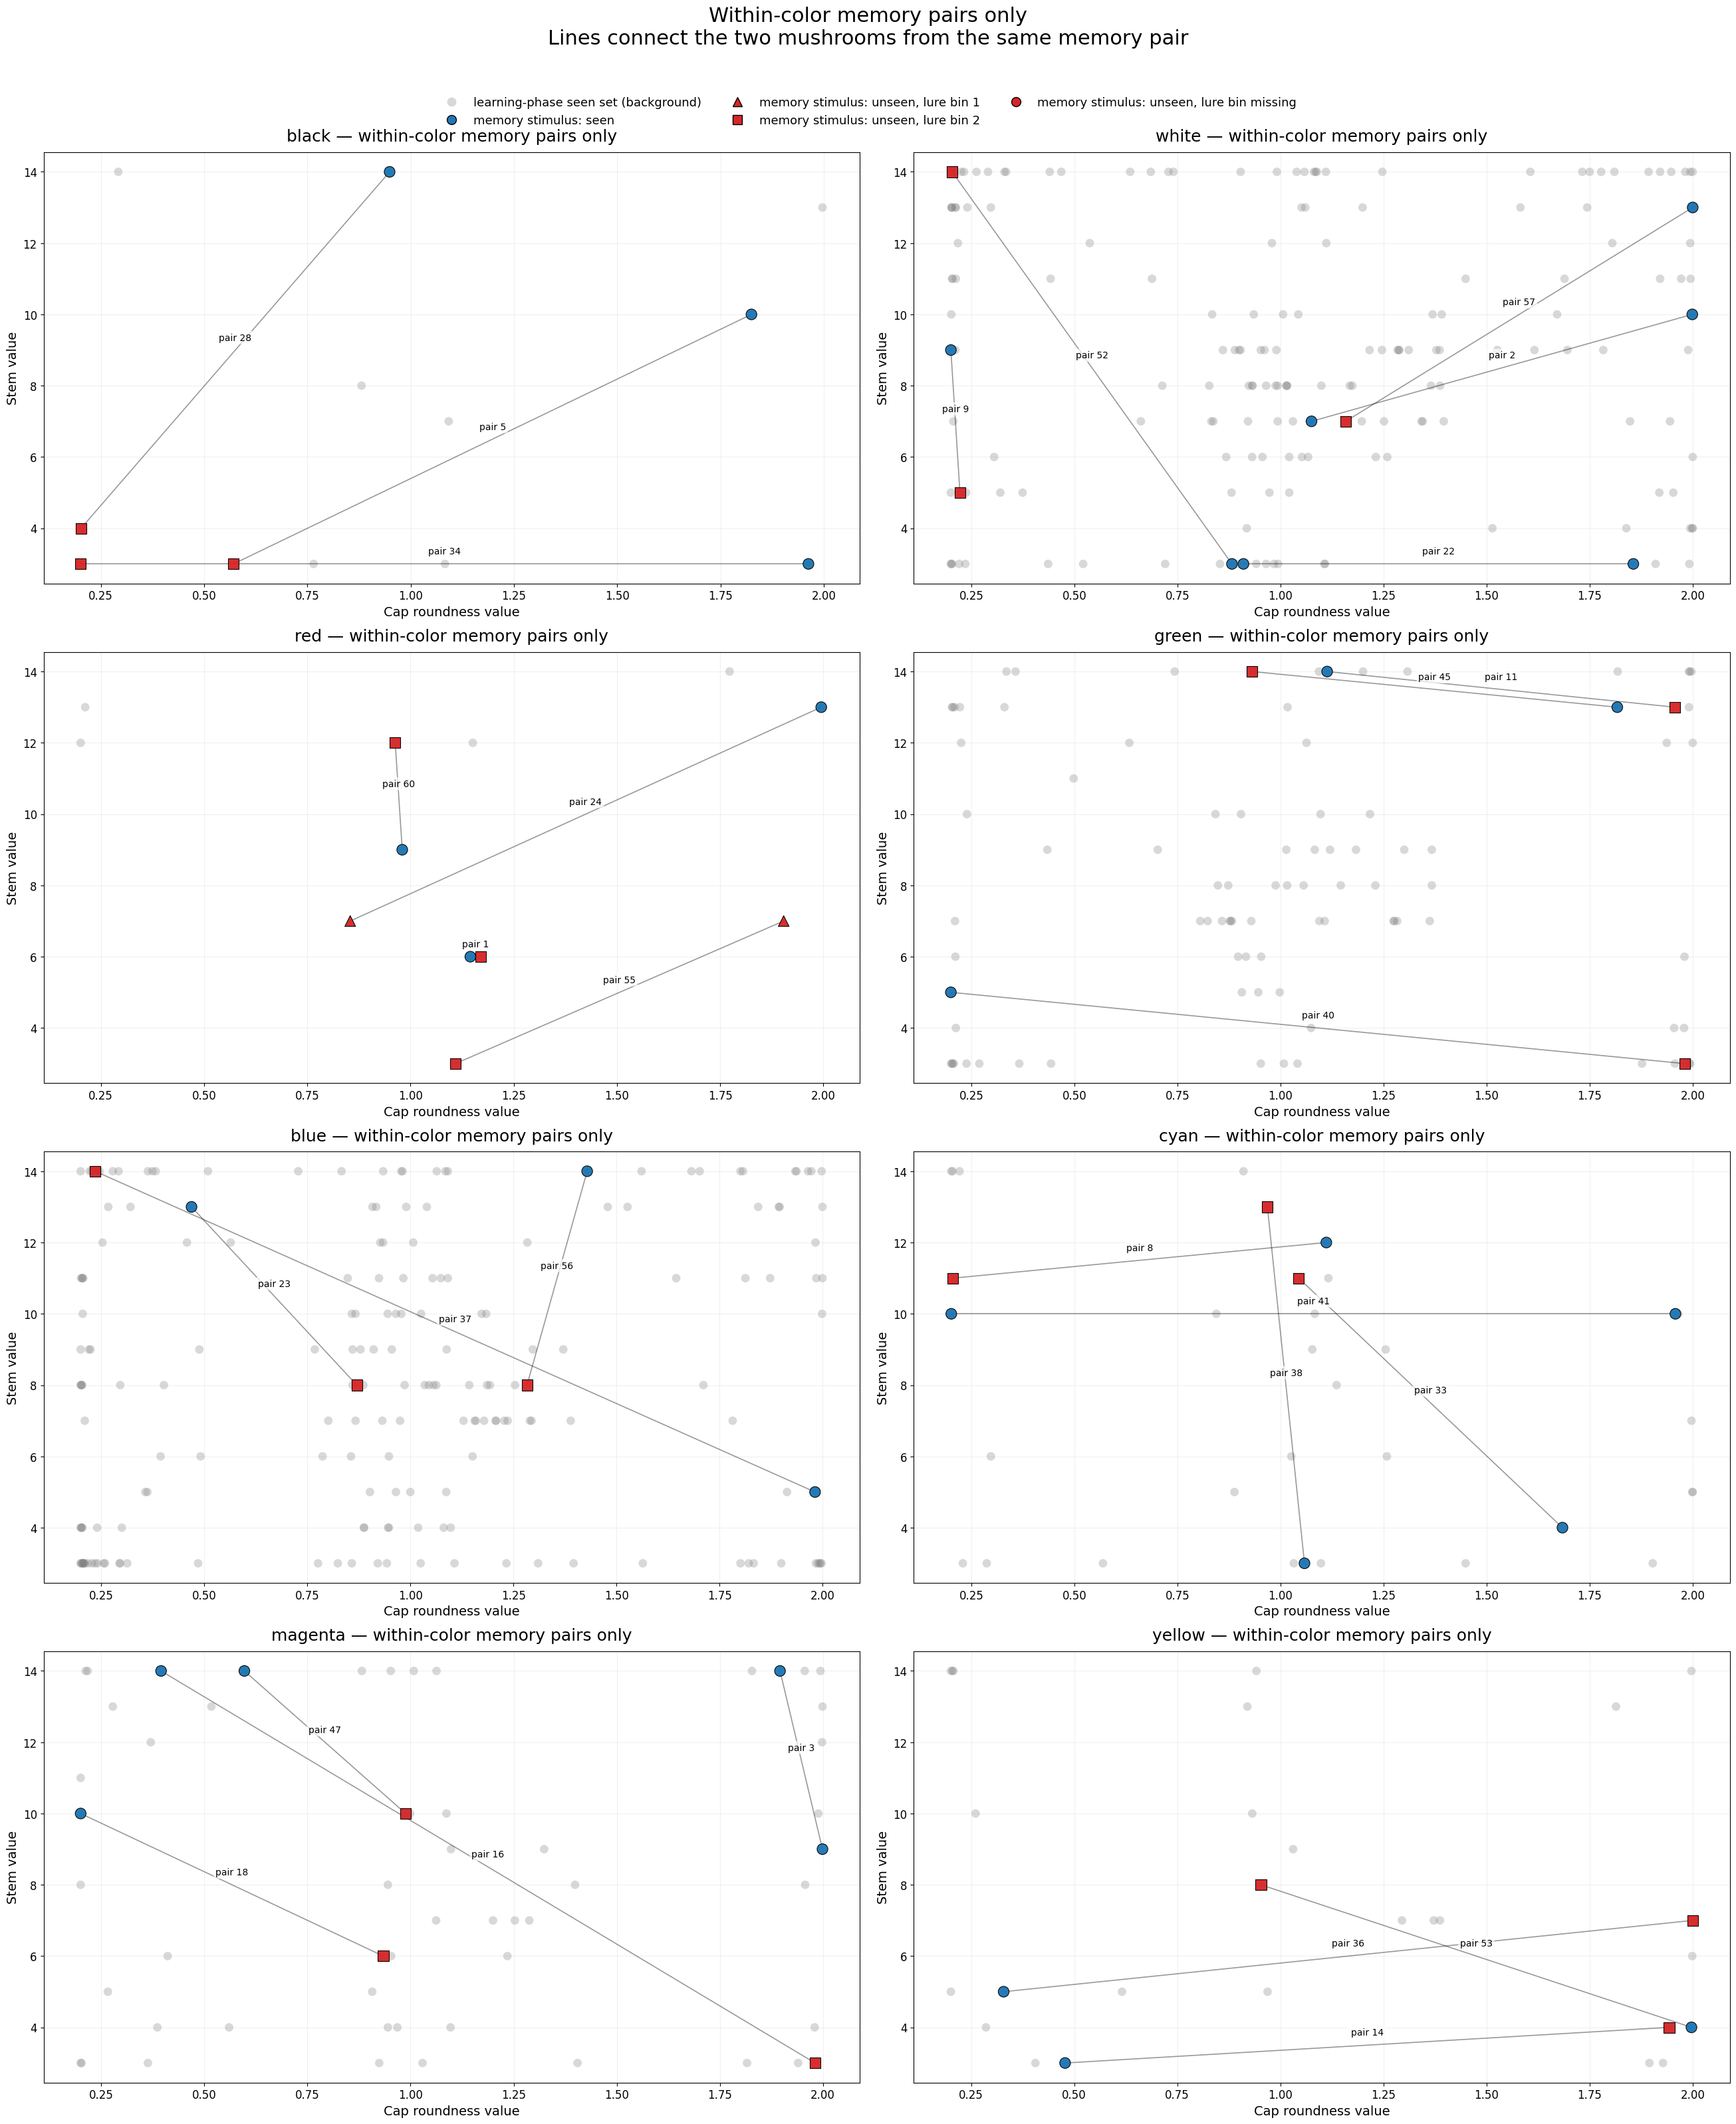

In [1]:

# ==========================================
# Memory-phase mushroom analysis
# Version:
#   1) Figure 1: all memory stimuli (both mushrooms from every pair), by color
#      - background = unique learning-phase seen mushrooms at 30% alpha
#      - foreground color = seen vs unseen
#      - unseen marker shape = lure bin (1 -> triangle, 2 -> square)
#      - no pair labels on this figure
#   2) Figure 2: within-color memory pairs only
#      - same seen/unseen color code and unseen lure-bin shape
#      - pair members connected by a line
#      - labeled with memory pair number (pair 1, pair 2, ...)
#
# This notebook/script does NOT save any CSV files.
# ==========================================

import csv
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

CSV_PATH = Path("data_ivy.csv")  # change if needed

# -------------------------
# 1) Robust CSV loader
# -------------------------
def robust_read_csv(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="replace", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        n_cols = len(header)

        for row in reader:
            if len(row) < n_cols:
                row = row + [""] * (n_cols - len(row))
            elif len(row) > n_cols:
                row = row[:n_cols]
            rows.append(row)

    return pd.DataFrame(rows, columns=header)


# -------------------------
# 2) Mushroom parsing helpers
# -------------------------
MUSHROOM_RE = re.compile(
    r"^(?P<color>[A-Za-z]+)-(?P<stem>\d+)-(?P<cap>-?\d+(?:\.\d+)?)"
)

COLOR_ORDER = ["black", "white", "red", "green", "blue", "cyan", "magenta", "yellow"]

def clean_name(s):
    s = "" if pd.isna(s) else str(s).strip()
    if s.endswith(".png"):
        s = s[:-4]
    return s

def parse_mushroom_fields(s):
    s = clean_name(s)
    m = MUSHROOM_RE.search(s)
    if not m:
        return {
            "mushroom_name_clean": s,
            "parsed_color": None,
            "stem_value": np.nan,
            "cap_value": np.nan,
        }
    return {
        "mushroom_name_clean": s,
        "parsed_color": m.group("color").lower(),
        "stem_value": float(m.group("stem")),
        "cap_value": float(m.group("cap")),
    }

def classify_seen_unseen(status_raw):
    s = "" if pd.isna(status_raw) else str(status_raw).strip().lower()
    if s.startswith("seen"):
        return "seen"
    if s.startswith("unseen"):
        return "unseen"
    return "unknown"

def coerce_bin(x):
    out = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    if pd.isna(out):
        return np.nan
    return int(out)

def add_parsed_fields(df, source_col):
    parsed = df[source_col].apply(parse_mushroom_fields).apply(pd.Series)
    out = pd.concat([df.reset_index(drop=True), parsed.reset_index(drop=True)], axis=1)
    return out

def apply_deterministic_jitter(df, group_cols=("parsed_color", "cap_value", "stem_value"), x_radius=0.018, y_radius=0.18):
    out = df.copy()
    out["plot_x"] = out["cap_value"].astype(float)
    out["plot_y"] = out["stem_value"].astype(float)

    grp = out.groupby(list(group_cols), dropna=False, sort=False)
    for _, idx in grp.groups.items():
        idx = list(idx)
        n = len(idx)
        if n <= 1:
            continue
        for k, row_i in enumerate(idx):
            angle = (2 * math.pi * k) / n
            out.loc[row_i, "plot_x"] = out.loc[row_i, "cap_value"] + x_radius * math.cos(angle)
            out.loc[row_i, "plot_y"] = out.loc[row_i, "stem_value"] + y_radius * math.sin(angle)
    return out

def normalize_color_order(colors_present):
    present = [c for c in COLOR_ORDER if c in set(colors_present)]
    leftover = [c for c in sorted(set(colors_present)) if c not in present]
    return present + leftover


# -------------------------
# 3) Load raw CSV
# -------------------------
df = robust_read_csv(CSV_PATH)
print("Raw shape:", df.shape)
print("\nTrial type counts:")
print(df["trial_type"].value_counts(dropna=False))


# -------------------------
# 4) Build learning-phase seen background
# -------------------------
explore_seen = df[df["trial_type"] == "explore_seen"].copy()
explore_seen["mushroom_name_source"] = np.where(
    explore_seen["imagefilename"].astype(str).str.strip() != "",
    explore_seen["imagefilename"],
    explore_seen["stimulus"],
)
learning_seen_df = add_parsed_fields(explore_seen, "mushroom_name_source")
learning_seen_df = learning_seen_df.dropna(subset=["cap_value", "stem_value"]).copy()
learning_seen_df = learning_seen_df.drop_duplicates(subset=["mushroom_name_clean"]).copy()
learning_seen_df["source"] = "learning_seen_background"

print("\nUnique learning-phase seen mushrooms:", len(learning_seen_df))


# -------------------------
# 5) Clean memory-choice rows
# -------------------------
memory_choice = df[df["trial_type"] == "memory_choice"].copy()
memory_choice["trial_index_num"] = pd.to_numeric(memory_choice["trial_index"], errors="coerce")

memory_choice = memory_choice[
    (memory_choice["left_mushroom_name"].astype(str).str.strip() != "") &
    (memory_choice["right_mushroom_name"].astype(str).str.strip() != "")
].copy()

memory_choice = (
    memory_choice
    .drop_duplicates(subset=["trial_index_num"], keep="last")
    .sort_values("trial_index_num")
    .reset_index(drop=True)
)

memory_choice["pair_number"] = np.arange(1, len(memory_choice) + 1)
memory_choice["pair_label"] = "pair " + memory_choice["pair_number"].astype(str)

print("Clean memory pairs:", len(memory_choice))


# -------------------------
# 6) Convert memory pairs to long format: BOTH stimuli per pair
# -------------------------
def build_memory_long(mc):
    left = mc[[
        "trial_index_num", "pair_number", "pair_label",
        "left_mushroom_name", "left_mushroom_status", "left_mushroom_lure_bin",
        "difficulty_label", "difficulty_bin", "lure_bin"
    ]].copy()
    left = left.rename(columns={
        "left_mushroom_name": "mushroom_name",
        "left_mushroom_status": "status_raw",
        "left_mushroom_lure_bin": "item_lure_bin",
    })
    left["side"] = "left"

    right = mc[[
        "trial_index_num", "pair_number", "pair_label",
        "right_mushroom_name", "right_mushroom_status", "right_mushroom_lure_bin",
        "difficulty_label", "difficulty_bin", "lure_bin"
    ]].copy()
    right = right.rename(columns={
        "right_mushroom_name": "mushroom_name",
        "right_mushroom_status": "status_raw",
        "right_mushroom_lure_bin": "item_lure_bin",
    })
    right["side"] = "right"

    long_df = pd.concat([left, right], axis=0, ignore_index=True)
    long_df["status_group"] = long_df["status_raw"].apply(classify_seen_unseen)
    long_df["item_lure_bin_num"] = long_df["item_lure_bin"].apply(coerce_bin)
    long_df = add_parsed_fields(long_df, "mushroom_name")

    pair_color_counts = (
        long_df.groupby(["trial_index_num", "parsed_color"], dropna=False)
        .size()
        .reset_index(name="n")
    )
    within_pairs = pair_color_counts.groupby("trial_index_num")["parsed_color"].nunique(dropna=True)
    within_pairs = within_pairs.rename("n_unique_colors").reset_index()

    long_df = long_df.merge(within_pairs, on="trial_index_num", how="left")
    long_df["within_color_pair"] = long_df["n_unique_colors"].eq(1)

    pair_color_lookup = (
        long_df[long_df["within_color_pair"]]
        .groupby("trial_index_num", as_index=False)["parsed_color"]
        .first()
        .rename(columns={"parsed_color": "within_pair_color"})
    )
    long_df = long_df.merge(pair_color_lookup, on="trial_index_num", how="left")

    return long_df

memory_stimuli_df = build_memory_long(memory_choice)
memory_stimuli_df = memory_stimuli_df.dropna(subset=["cap_value", "stem_value"]).copy()
memory_stimuli_df = apply_deterministic_jitter(memory_stimuli_df)

print("Memory stimuli rows (both sides together):", len(memory_stimuli_df))
print("Within-color memory pairs:", memory_stimuli_df[["trial_index_num", "within_color_pair"]].drop_duplicates()["within_color_pair"].sum())


# -------------------------
# 7) Summary tables
# -------------------------
summary_overview = pd.DataFrame({
    "metric": [
        "clean_memory_pairs",
        "all_memory_stimuli",
        "within_color_pairs",
        "cross_color_pairs",
        "unique_learning_seen_background"
    ],
    "value": [
        len(memory_choice),
        len(memory_stimuli_df),
        int(memory_stimuli_df[["trial_index_num", "within_color_pair"]].drop_duplicates()["within_color_pair"].sum()),
        int((~memory_stimuli_df[["trial_index_num", "within_color_pair"]].drop_duplicates()["within_color_pair"]).sum()),
        len(learning_seen_df),
    ]
})

stimuli_seen_counts = (
    memory_stimuli_df.groupby("status_group", dropna=False)
    .size()
    .reset_index(name="n_memory_stimuli")
    .sort_values("status_group")
)

stimuli_by_color_seen = (
    memory_stimuli_df.groupby(["parsed_color", "status_group"], dropna=False)
    .size()
    .reset_index(name="n_memory_stimuli")
    .sort_values(["parsed_color", "status_group"])
)

unseen_lure_counts = (
    memory_stimuli_df[memory_stimuli_df["status_group"] == "unseen"]
    .groupby("item_lure_bin_num", dropna=False)
    .size()
    .reset_index(name="n_unseen_memory_stimuli")
    .sort_values("item_lure_bin_num")
)

question_lure_difficulty = (
    memory_choice.assign(
        lure_bin_num=pd.to_numeric(memory_choice["lure_bin"], errors="coerce"),
        difficulty_bin_num=pd.to_numeric(memory_choice["difficulty_bin"], errors="coerce"),
    )
    .groupby(["difficulty_label", "lure_bin_num"], dropna=False)
    .size()
    .reset_index(name="n_pairs")
    .sort_values(["difficulty_label", "lure_bin_num"])
)

within_color_pair_counts = (
    memory_stimuli_df[memory_stimuli_df["within_color_pair"]]
    [["trial_index_num", "pair_label", "within_pair_color"]]
    .drop_duplicates()
    .groupby("within_pair_color", dropna=False)
    .size()
    .reset_index(name="n_within_color_pairs")
    .sort_values("within_pair_color")
)

print("\nOverview:")
display(summary_overview)

print("\nMemory stimuli by seen/unseen:")
display(stimuli_seen_counts)

print("\nMemory stimuli by color and seen/unseen:")
display(stimuli_by_color_seen)

print("\nUnseen memory stimuli by item lure bin:")
display(unseen_lure_counts)

print("\nQuestion-level lure difficulty counts:")
display(question_lure_difficulty)

print("\nWithin-color pair counts by color:")
display(within_color_pair_counts)


# -------------------------
# 8) Plot helpers
# -------------------------
SEEN_COLOR = "#1f77b4"
UNSEEN_COLOR = "#d62728"
BACKGROUND_COLOR = "#7f7f7f"

def marker_for_row(row):
    if row["status_group"] == "seen":
        return "o"
    lb = row["item_lure_bin_num"]
    if pd.isna(lb):
        return "o"
    if int(lb) == 1:
        return "^"
    if int(lb) == 2:
        return "s"
    return "o"

def build_figure_axes(colors, figsize):
    n = len(colors)
    ncols = 2
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.array(axes).reshape(-1)
    return fig, axes

def add_shared_legend(fig):
    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=10, markerfacecolor=BACKGROUND_COLOR,
               markeredgecolor="none", alpha=0.30, label="learning-phase seen set (background)"),
        Line2D([0], [0], marker="o", linestyle="", markersize=10, markerfacecolor=SEEN_COLOR,
               markeredgecolor="black", label="memory stimulus: seen"),
        Line2D([0], [0], marker="^", linestyle="", markersize=10, markerfacecolor=UNSEEN_COLOR,
               markeredgecolor="black", label="memory stimulus: unseen, lure bin 1"),
        Line2D([0], [0], marker="s", linestyle="", markersize=10, markerfacecolor=UNSEEN_COLOR,
               markeredgecolor="black", label="memory stimulus: unseen, lure bin 2"),
        Line2D([0], [0], marker="o", linestyle="", markersize=10, markerfacecolor=UNSEEN_COLOR,
               markeredgecolor="black", label="memory stimulus: unseen, lure bin missing"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=13)

def stylize_axis(ax, title):
    ax.set_title(title, fontsize=18, pad=12)
    ax.set_xlabel("Cap roundness value", fontsize=14)
    ax.set_ylabel("Stem value", fontsize=14)
    ax.grid(alpha=0.18)
    ax.tick_params(labelsize=12)

def plot_all_memory_stimuli_by_color(memory_df, background_df):
    colors = normalize_color_order(memory_df["parsed_color"].dropna().tolist())
    fig, axes = build_figure_axes(colors, figsize=(26, 30))

    for ax, color_name in zip(axes, colors):
        bg = background_df[background_df["parsed_color"] == color_name]
        sub = memory_df[memory_df["parsed_color"] == color_name]

        if len(bg):
            ax.scatter(
                bg["cap_value"], bg["stem_value"],
                s=85, c=BACKGROUND_COLOR, alpha=0.30, edgecolors="none", zorder=1
            )

        # plot by marker groups
        for marker in ["o", "^", "s"]:
            sub_m = sub[sub.apply(marker_for_row, axis=1) == marker]
            if len(sub_m) == 0:
                continue

            point_colors = np.where(sub_m["status_group"].eq("seen"), SEEN_COLOR, UNSEEN_COLOR)
            ax.scatter(
                sub_m["plot_x"], sub_m["plot_y"],
                s=125,
                c=point_colors,
                marker=marker,
                edgecolors="black",
                linewidths=0.7,
                alpha=0.95,
                zorder=3,
            )

        stylize_axis(ax, f"{color_name} — all memory stimuli")

    for ax in axes[len(colors):]:
        ax.axis("off")

    add_shared_legend(fig)
    fig.suptitle(
        "All memory stimuli (both mushrooms from every memory pair)\nBackground = unique learning-phase seen set",
        fontsize=22, y=1.06
    )
    plt.show()

def plot_within_color_pairs(memory_df, background_df):
    pair_df = memory_df[memory_df["within_color_pair"]].copy()
    colors = normalize_color_order(pair_df["parsed_color"].dropna().tolist())
    fig, axes = build_figure_axes(colors, figsize=(26, 30))

    for ax, color_name in zip(axes, colors):
        bg = background_df[background_df["parsed_color"] == color_name]
        sub = pair_df[pair_df["parsed_color"] == color_name].copy()

        if len(bg):
            ax.scatter(
                bg["cap_value"], bg["stem_value"],
                s=85, c=BACKGROUND_COLOR, alpha=0.30, edgecolors="none", zorder=1
            )

        # connect each within-color pair
        for trial_idx, pair_rows in sub.groupby("trial_index_num", sort=True):
            pair_rows = pair_rows.sort_values("side")
            if len(pair_rows) >= 2:
                ax.plot(
                    pair_rows["plot_x"], pair_rows["plot_y"],
                    color="black", linewidth=1.2, alpha=0.40, zorder=2
                )
                mx = pair_rows["plot_x"].mean()
                my = pair_rows["plot_y"].mean()
                pair_label = pair_rows["pair_label"].iloc[0]
                ax.text(
                    mx, my + 0.22, pair_label,
                    fontsize=10, ha="center", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.70),
                    zorder=5
                )

        for marker in ["o", "^", "s"]:
            sub_m = sub[sub.apply(marker_for_row, axis=1) == marker]
            if len(sub_m) == 0:
                continue

            point_colors = np.where(sub_m["status_group"].eq("seen"), SEEN_COLOR, UNSEEN_COLOR)
            ax.scatter(
                sub_m["plot_x"], sub_m["plot_y"],
                s=135,
                c=point_colors,
                marker=marker,
                edgecolors="black",
                linewidths=0.8,
                alpha=0.97,
                zorder=4,
            )

        stylize_axis(ax, f"{color_name} — within-color memory pairs only")

    for ax in axes[len(colors):]:
        ax.axis("off")

    add_shared_legend(fig)
    fig.suptitle(
        "Within-color memory pairs only\nLines connect the two mushrooms from the same memory pair",
        fontsize=22, y=1.06
    )
    plt.show()


# -------------------------
# 9) Make the plots
# -------------------------
plot_all_memory_stimuli_by_color(memory_stimuli_df, learning_seen_df)
plot_within_color_pairs(memory_stimuli_df, learning_seen_df)
